**Install and import packages**

In [ ]:
!pip -q install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 29.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_validate

**Step 1. Load the dataset**

In [ ]:
df_qsar = pd.read_csv("DPP4_QSAR_dataset_parent_cleaned_locked.csv")

print("Dataset shape:", df_qsar.shape)
print(df_qsar.columns.tolist())

smiles_col = "parent_smiles"
target_col = "pIC50_median"

print("Missing parent SMILES:", df_qsar[smiles_col].isna().sum())
print("Missing pIC50:", df_qsar[target_col].isna().sum())

df_qsar.head()

Dataset shape: (3666, 25)
['parent_smiles', 'molecule_chembl_id', 'pref_name', 'canonical_smiles_examples', 'n_records', 'IC50_nM_median', 'IC50_nM_min', 'IC50_nM_max', 'pIC50_median', 'pIC50_min', 'pIC50_max', 'pIC50_std', 'pchembl_median', 'assay_type', 'assay_chembl_id', 'document_chembl_id', 'mw_freebase', 'alogp', 'hba', 'hbd', 'psa', 'rtb', 'num_ro5_violations', 'pIC50_range', 'activity_class']
Missing parent SMILES: 0
Missing pIC50: 0


,parent_smiles,molecule_chembl_id,pref_name,canonical_smiles_examples,n_records,IC50_nM_median,IC50_nM_min,IC50_nM_max,pIC50_median,pIC50_min,...,document_chembl_id,mw_freebase,alogp,hba,hbd,psa,rtb,num_ro5_violations,pIC50_range,activity_class
0,Brc1nc2n(n1)CC(c1cc3ccccc3o1)=NN2,CHEMBL4246951,NaN,Brc1nc2n(n1)CC(c1cc3ccccc3o1)=NN2,1,28050.00,28050.00,28050.00,4.552067,4.552067,...,CHEMBL4229387,318.13,2.62,6.0,1.0,68.24,1.0,0.0,0.0,Low
1,C#CCN(CC#N)C(=O)[C@@H]1C[C@H](C(=O)N(C)C)[C@H]...,CHEMBL260701,NaN,C#CCN(CC#N)C(=O)[C@@H]1C[C@H](C(=O)N(C)C)[C@H]...,1,60.00,60.00,60.00,7.221849,7.221849,...,CHEMBL1143890,276.34,-0.57,4.0,1.0,76.44,4.0,0.0,0.0,High
2,C#CCn1c(=O)n(C)c(=O)c2c1nc(N1CCCC(N)C1)n2Cc1cc...,CHEMBL3913618,NaN,C#CCn1c(=O)n(C)c(=O)c2c1nc(N1CCCC(N)C1)n2Cc1cc...,1,16.00,16.00,16.00,7.795880,7.795880,...,CHEMBL3886676,417.47,0.38,9.0,1.0,114.87,4.0,0.0,0.0,High
3,C#CCn1c(N2CCC[C@H](N)C2)nc2c1c(=O)n(Cc1nc(C)c3...,CHEMBL5277490,NaN,C#CCn1c(N2CCC[C@H](N)C2)nc2c1c(=O)n(Cc1nc(C)c3...,1,1.33,1.33,1.33,8.876148,8.876148,...,CHEMBL5244277,458.53,0.76,10.0,1.0,116.86,4.0,0.0,0.0,High
4,C#Cc1cnc(N2CCC[C@@H](N)C2)n(Cc2ccccc2C#N)c1=O,CHEMBL1650422,NaN,C#Cc1cnc(N2CCC[C@@H](N)C2)n(Cc2ccccc2C#N)c1=O,1,5.00,5.00,5.00,8.301030,8.301030,...,CHEMBL1649419,333.40,1.07,6.0,1.0,87.94,3.0,0.0,0.0,High


**Step 2. Covert SMILES to Molecules**

In [ ]:
df_qsar["mol"] = df_qsar[smiles_col].apply(Chem.MolFromSmiles)

valid_mol_count = df_qsar["mol"].notna().sum()
invalid_mol_count = df_qsar["mol"].isna().sum()

print("Valid molecules:", valid_mol_count)
print("Invalid molecules:", invalid_mol_count)

Valid molecules: 3666
Invalid molecules: 0


**Step 3. Generate Morgan Fingerprint**

In [ ]:
morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048,
    includeChirality=True
)

def mol_to_morgan_fp(mol):
    fp = morgan_generator.GetFingerprint(mol)
    arr = np.zeros((2048,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

X = np.array([mol_to_morgan_fp(mol) for mol in df_qsar["mol"]])
y = df_qsar[target_col].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3666, 2048)
y shape: (3666,)


**Step 4. Reproduce the same train/test split**

In [ ]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

# Stratified regression split using pIC50 bins
y_bins = pd.qcut(y, q=5, labels=False, duplicates="drop")

indices = np.arange(len(df_qsar))

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X,
    y,
    indices,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_bins
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (2932, 2048)
Test set: (734, 2048)


**Step 5. Define the final model**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

final_model_name = "Tuned Random Forest"

final_model = RandomForestRegressor(
    n_estimators=300,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features=0.3,
    max_depth=None,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print(final_model_name)
print(final_model)

Tuned Random Forest
RandomForestRegressor(max_features=0.3, min_samples_split=5, n_estimators=300,
                      n_jobs=-1, random_state=42)


**Step 6. Define CV Setting**

In [ ]:
from sklearn.model_selection import StratifiedKFold

y_train_bins = pd.qcut(y_train, q=5, labels=False, duplicates="drop")

cv_splitter = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_splits = list(cv_splitter.split(X_train, y_train_bins))

print("Number of CV folds:", len(cv_splits))

Number of CV folds: 5


**Step 7.Calculate real CV performance**

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error"
}

real_cv_scores = cross_validate(
    final_model,
    X_train,
    y_train,
    cv=cv_splits,
    scoring=scoring,
    return_train_score=True,
    n_jobs=1
)

real_cv_r2 = real_cv_scores["test_r2"].mean()
real_cv_mae = -real_cv_scores["test_mae"].mean()
real_cv_rmse = -real_cv_scores["test_rmse"].mean()

print("Real CV R2:", real_cv_r2)
print("Real CV MAE:", real_cv_mae)
print("Real CV RMSE:", real_cv_rmse)

Real CV R2: 0.6446002282949065
Real CV MAE: 0.514986817238146
Real CV RMSE: 0.7207700193327881


**Step 8. Run Y-randomization**

In [ ]:
N_RANDOMIZATIONS = 20

rng = np.random.default_rng(RANDOM_STATE)

y_randomization_results = []

for i in range(N_RANDOMIZATIONS):
    print(f"Running Y-randomization {i + 1}/{N_RANDOMIZATIONS}")

    # Shuffle training labels
    y_train_shuffled = rng.permutation(y_train)

    # Same model type, but different random_state per run
    shuffled_model = RandomForestRegressor(
        n_estimators=300,
        min_samples_split=5,
        min_samples_leaf=1,
        max_features=0.3,
        max_depth=None,
        random_state=RANDOM_STATE + i,
        n_jobs=-1
    )

    shuffled_scores = cross_validate(
        shuffled_model,
        X_train,
        y_train_shuffled,
        cv=cv_splits,
        scoring=scoring,
        return_train_score=True,
        n_jobs=1
    )

    y_randomization_results.append({
        "Randomization": i + 1,
        "Train_R2_mean": shuffled_scores["train_r2"].mean(),
        "CV_R2_mean": shuffled_scores["test_r2"].mean(),
        "CV_R2_std": shuffled_scores["test_r2"].std(),
        "CV_MAE_mean": -shuffled_scores["test_mae"].mean(),
        "CV_RMSE_mean": -shuffled_scores["test_rmse"].mean()
    })

y_randomization_df = pd.DataFrame(y_randomization_results)

y_randomization_df.head()

Running Y-randomization 1/20
Running Y-randomization 2/20
Running Y-randomization 3/20
Running Y-randomization 4/20
Running Y-randomization 5/20
Running Y-randomization 6/20
Running Y-randomization 7/20
Running Y-randomization 8/20
Running Y-randomization 9/20
Running Y-randomization 10/20
Running Y-randomization 11/20
Running Y-randomization 12/20
Running Y-randomization 13/20
Running Y-randomization 14/20
Running Y-randomization 15/20
Running Y-randomization 16/20
Running Y-randomization 17/20
Running Y-randomization 18/20
Running Y-randomization 19/20
Running Y-randomization 20/20


,Randomization,Train_R2_mean,CV_R2_mean,CV_R2_std,CV_MAE_mean,CV_RMSE_mean
0,1,0.769125,-0.137856,0.028023,1.028609,1.288967
1,2,0.772002,-0.133372,0.023863,1.024044,1.286092
2,3,0.770993,-0.160112,0.032780,1.043937,1.301612
3,4,0.776055,-0.115511,0.023348,1.021386,1.277143
4,5,0.774149,-0.125266,0.031061,1.022961,1.280917


**Step 9. Summarize Y-randomization results**

In [ ]:
y_randomization_summary = pd.DataFrame([{
    "Final_Model": final_model_name,
    "Real_CV_R2": real_cv_r2,
    "Real_CV_MAE": real_cv_mae,
    "Real_CV_RMSE": real_cv_rmse,
    "Randomized_CV_R2_mean": y_randomization_df["CV_R2_mean"].mean(),
    "Randomized_CV_R2_std": y_randomization_df["CV_R2_mean"].std(),
    "Randomized_CV_R2_max": y_randomization_df["CV_R2_mean"].max(),
    "Randomized_CV_R2_min": y_randomization_df["CV_R2_mean"].min(),
    "N_randomizations": N_RANDOMIZATIONS
}])

display(y_randomization_summary)

,Final_Model,Real_CV_R2,Real_CV_MAE,Real_CV_RMSE,Randomized_CV_R2_mean,Randomized_CV_R2_std,Randomized_CV_R2_max,Randomized_CV_R2_min,N_randomizations
0,Tuned Random Forest,0.6446,0.514987,0.72077,-0.131,0.017434,-0.092715,-0.167863,20


**Step 10. Plot Y-randomization result**

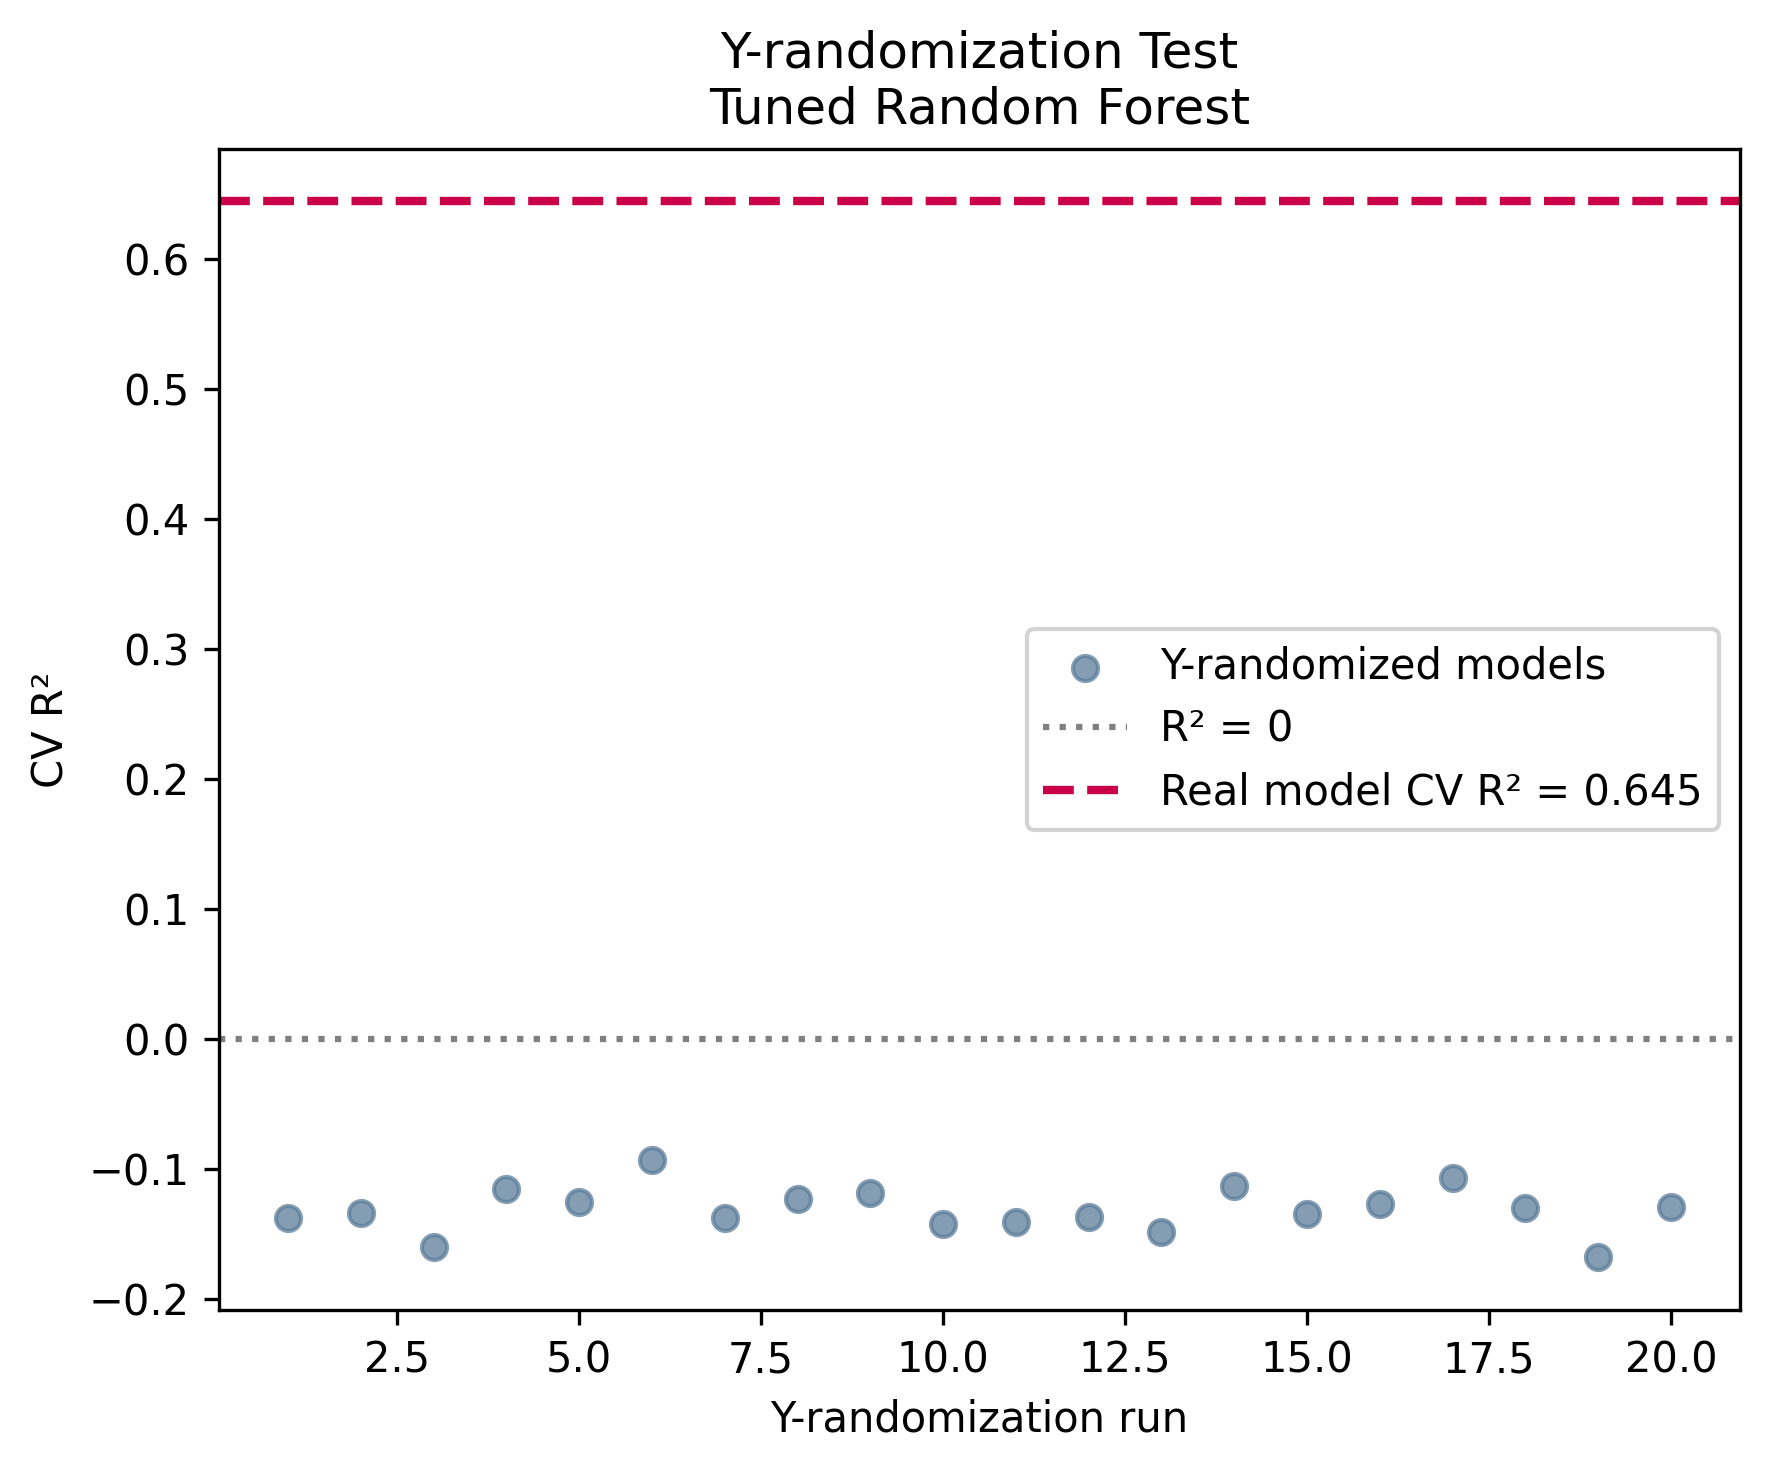

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5), dpi=300)

plt.scatter(
    np.arange(1, N_RANDOMIZATIONS + 1),
    y_randomization_df["CV_R2_mean"],
    color="xkcd:slate blue",
    alpha=0.75,
    label="Y-randomized models"
)

plt.axhline(
    0,
    color="gray",
    linestyle=":",
    linewidth=1.5,
    label="R² = 0"
)

plt.axhline(
    real_cv_r2,
    color="xkcd:ruby",
    linestyle="--",
    linewidth=2,
    label=f"Real model CV R² = {real_cv_r2:.3f}"
)

plt.xlabel("Y-randomization run")
plt.ylabel("CV R²")
plt.title(f"Y-randomization Test\n{final_model_name}")

plt.legend(
    frameon=True,
    fancybox=True,
    framealpha=1,
    facecolor="white",
    edgecolor="lightgray"
)

plt.tight_layout()

plt.savefig(
    "DPP4_Y_randomization_plot_chirality.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Step 11. Save Results**

In [ ]:
y_randomization_df.to_csv(
    "DPP4_RF_tuned_Y_randomization_results_chirality.csv",
    index=False
)

y_randomization_summary.to_csv(
    "DPP4_RF_tuned_Y_randomization_summary_chirality.csv",
    index=False
)

print("Saved:")
print("DPP4_RF_tuned_Y_randomization_results_chirality.csv")
print("DPP4_RF_tuned_Y_randomization_summary_chirality.csv")
print("DPP4_Y_randomization_plot_chirality.png")

Saved:
DPP4_RF_tuned_Y_randomization_results_chirality.csv
DPP4_RF_tuned_Y_randomization_summary_chirality.csv
DPP4_Y_randomization_plot_chirality.png
